# CELL 1: Chuẩn hóa kích thước 600x600 chuẩn JPG

In [3]:
import os
import cv2
import glob

# Danh sách các thư mục cần chuẩn hóa
FOLDERS = [r".\Face_Database", r".\Face_Test"]

def resize_and_convert_to_jpg(image_path, target_size=(600, 600)):
    img = cv2.imread(image_path)
    if img is None:
        print(f"⚠️ Không thể đọc ảnh: {image_path}")
        return None
    
    h, w = img.shape[:2]
    scale = min(target_size[0] / w, target_size[1] / h)
    nw, nh = int(w * scale), int(h * scale)
    
    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_CUBIC
    resized_img = cv2.resize(img, (nw, nh), interpolation=interpolation)
    
    # Thêm viền đen 600x600 giữ tỉ lệ mặt
    padded_img = cv2.copyMakeBorder(
        resized_img, 
        top=(target_size[1] - nh) // 2, 
        bottom=target_size[1] - nh - (target_size[1] - nh) // 2,
        left=(target_size[0] - nw) // 2, 
        right=target_size[0] - nw - (target_size[0] - nw) // 2,
        borderType=cv2.BORDER_CONSTANT, 
        value=[0, 0, 0]
    )
    
    base_name = os.path.splitext(image_path)[0]
    new_jpg_path = f"{base_name}.jpg"
    cv2.imwrite(new_jpg_path, padded_img, [int(cv2.IMWRITE_JPEG_QUALITY), 95])
    
    if image_path.lower().endswith('.png') and os.path.exists(new_jpg_path):
        os.remove(image_path)
        
    return new_jpg_path

supported_exts = ('.jpg', '.jpeg', '.png')
for folder in FOLDERS:
    if not os.path.exists(folder):
        os.makedirs(folder)
        continue
    all_files = glob.glob(os.path.join(folder, "*.*"))
    image_files = [f for f in all_files if f.lower().endswith(supported_exts)]
    
    print(f"🔄 Đang chuẩn hóa {len(image_files)} ảnh trong thư mục '{folder}'...")
    for img_p in image_files:
        resize_and_convert_to_jpg(img_p)

print("✅ Hoàn tất chuẩn hóa ảnh về 600x600 chuẩn JPG cho cả 2 thư mục!")

🔄 Đang chuẩn hóa 18 ảnh trong thư mục '.\Face_Database'...
🔄 Đang chuẩn hóa 75 ảnh trong thư mục '.\Face_Test'...
✅ Hoàn tất chuẩn hóa ảnh về 600x600 chuẩn JPG cho cả 2 thư mục!


# CELL 2: Tạo test_label.csv chứa image_path và true_name cho tập Test

In [4]:
import os
import glob
import pandas as pd

TEST_DIR = r".\Face_Test"
CSV_PATH = "test_label.csv"

# Ánh xạ tiền tố file thành tên người nhà
NAME_MAP = {
    "dat": "Đạt",
    "quan": "Quân",
    "tien": "Tiến",
    "vu": "Vũ"
}

jpg_files = glob.glob(os.path.join(TEST_DIR, "*.jpg"))

data = []
for file_path in jpg_files:
    filename = os.path.basename(file_path)
    prefix = filename.split('_')[0].lower()
    true_name = NAME_MAP.get(prefix, "Người lạ")
    
    data.append({
        "image_path": file_path,
        "true_name": true_name
    })

df = pd.DataFrame(data)
df.to_csv(CSV_PATH, index=False, encoding='utf-8-sig')
print(f"✅ Đã tạo file '{CSV_PATH}' chứa {len(df)} mẫu thử nghiệm thực tế!")

✅ Đã tạo file 'test_label.csv' chứa 75 mẫu thử nghiệm thực tế!


# CELL 3: Trích xuất Vector CSDL từ Face_Database -> registered_db.pkl

In [5]:
import os
import glob
import pickle
from deepface import DeepFace

DB_DIR = r".\Face_Database"
PKL_PATH = "registered_db.pkl"

NAME_MAP = {
    "dat": "Đạt",
    "quan": "Quân",
    "tien": "Tiến",
    "vu": "Vũ"
}

jpg_files = glob.glob(os.path.join(DB_DIR, "*.jpg"))
registered_db = {}

print(f"🧠 Đang trích xuất Vector mẫu từ kho dữ liệu gốc '{DB_DIR}'...")

for idx, file_path in enumerate(jpg_files):
    filename = os.path.basename(file_path)
    prefix = filename.split('_')[0].lower()
    person_name = NAME_MAP.get(prefix, "Người lạ")
    
    # CSDL mẫu đăng ký tuyệt đối không lưu Người lạ
    if person_name == "Người lạ":
        continue
        
    try:
        res = DeepFace.represent(
            img_path=file_path, 
            model_name="Facenet", 
            enforce_detection=False, 
            detector_backend="mtcnn"
        )
        
        if len(res) > 0:
            embedding = res[0]["embedding"]
            uid = f"user_{person_name}"
            sample_id = f"sample_{idx+1}"
            
            if uid not in registered_db:
                registered_db[uid] = {
                    "name": person_name,
                    "samples": {}
                }
            
            registered_db[uid]["samples"][sample_id] = {
                "embedding": embedding,
                "image_path": file_path
            }
            print(f"  [+] Đã đăng ký mẫu ({idx+1}/{len(jpg_files)}): {filename} -> {person_name}")
            
    except Exception as e:
        print(f"  [-] Lỗi trích xuất {filename}: {e}")

with open(PKL_PATH, "wb") as f:
    pickle.dump(registered_db, f)

print(f"\n🎉 Đã khởi tạo CSDL mẫu cho {len(registered_db)} người dùng và lưu tại '{PKL_PATH}'!")

🧠 Đang trích xuất Vector mẫu từ kho dữ liệu gốc '.\Face_Database'...
  [+] Đã đăng ký mẫu (1/18): dat_12.jpg -> Đạt
  [+] Đã đăng ký mẫu (2/18): dat_14.jpg -> Đạt
  [+] Đã đăng ký mẫu (3/18): dat_16.jpg -> Đạt
  [+] Đã đăng ký mẫu (4/18): dat_2.jpg -> Đạt
  [+] Đã đăng ký mẫu (5/18): dat_20.jpg -> Đạt
  [+] Đã đăng ký mẫu (6/18): dat_5.jpg -> Đạt
  [+] Đã đăng ký mẫu (7/18): quan_10.jpg -> Quân
  [+] Đã đăng ký mẫu (8/18): quan_11.jpg -> Quân
  [+] Đã đăng ký mẫu (9/18): quan_13.jpg -> Quân
  [+] Đã đăng ký mẫu (10/18): quan_5.jpg -> Quân
  [+] Đã đăng ký mẫu (11/18): quan_7.jpg -> Quân
  [+] Đã đăng ký mẫu (12/18): tien_12.jpg -> Tiến
  [+] Đã đăng ký mẫu (13/18): tien_14.jpg -> Tiến
  [+] Đã đăng ký mẫu (14/18): tien_4.jpg -> Tiến
  [+] Đã đăng ký mẫu (15/18): tien_8.jpg -> Tiến
  [+] Đã đăng ký mẫu (16/18): vu_1.jpg -> Vũ
  [+] Đã đăng ký mẫu (17/18): vu_3.jpg -> Vũ
  [+] Đã đăng ký mẫu (18/18): vu_5.jpg -> Vũ

🎉 Đã khởi tạo CSDL mẫu cho 4 người dùng và lưu tại 'registered_db.pkl'!


# CELL 4: Chạy Mô Phỏng Vận Hành Thực Tế & Đánh Giá Chỉ Số

🚀 Đang chạy dự đoán cho từng ảnh trong thư mục Face_Test...
  [1/75] dat_1.jpg | Thực tế: Đạt -> Dự đoán: Đạt
  [2/75] dat_10.jpg | Thực tế: Đạt -> Dự đoán: Người lạ
  [3/75] dat_11.jpg | Thực tế: Đạt -> Dự đoán: Đạt
  [4/75] dat_13.jpg | Thực tế: Đạt -> Dự đoán: Đạt
  [5/75] dat_15.jpg | Thực tế: Đạt -> Dự đoán: Quân
  [6/75] dat_17.jpg | Thực tế: Đạt -> Dự đoán: Tiến
  [7/75] dat_18.jpg | Thực tế: Đạt -> Dự đoán: Đạt
  [8/75] dat_19.jpg | Thực tế: Đạt -> Dự đoán: Đạt
  [9/75] dat_21.jpg | Thực tế: Đạt -> Dự đoán: Đạt
  [10/75] dat_22.jpg | Thực tế: Đạt -> Dự đoán: Đạt
  [11/75] dat_23.jpg | Thực tế: Đạt -> Dự đoán: Đạt
  [12/75] dat_24.jpg | Thực tế: Đạt -> Dự đoán: Đạt
  [13/75] dat_25.jpg | Thực tế: Đạt -> Dự đoán: Đạt
  [14/75] dat_3.jpg | Thực tế: Đạt -> Dự đoán: Đạt
  [15/75] dat_4.jpg | Thực tế: Đạt -> Dự đoán: Đạt
  [16/75] dat_6.jpg | Thực tế: Đạt -> Dự đoán: Đạt
  [17/75] dat_7.jpg | Thực tế: Đạt -> Dự đoán: Đạt
  [18/75] dat_8.jpg | Thực tế: Đạt -> Dự đoán: Đạt
  [19/75] da

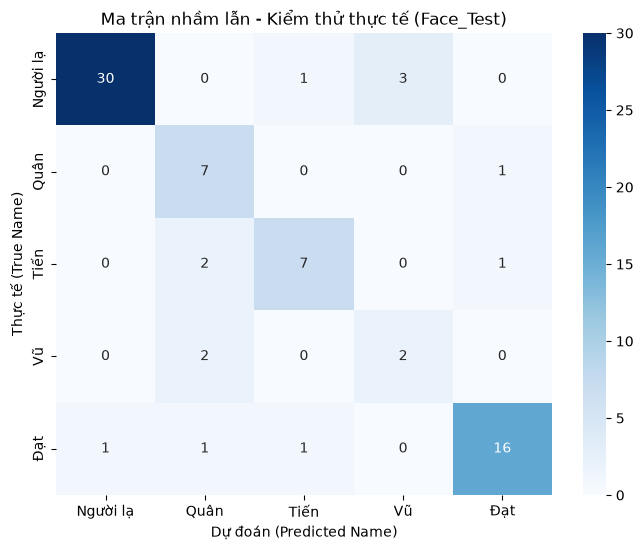

In [6]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from deepface import DeepFace
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

FACENET_THRESHOLD = 0.40
CSV_PATH = "test_label.csv"
PKL_PATH = "registered_db.pkl"

# 1. Load CSDL đăng ký
with open(PKL_PATH, "rb") as f:
    registered_db = pickle.load(f)

df = pd.read_csv(CSV_PATH)

def calculate_cosine_distance(source_emb, test_emb):
    a, b = np.array(source_emb), np.array(test_emb)
    return 1 - np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def predict_face(test_img_path, db):
    try:
        res = DeepFace.represent(
            img_path=test_img_path, 
            model_name="Facenet", 
            enforce_detection=False, 
            detector_backend="mtcnn"
        )
        if len(res) == 0:
            return "Không thấy mặt"
        
        target_emb = res[0]["embedding"]
        best_match_name = "Người lạ"
        min_distance = float("inf")

        for uid, user_data in db.items():
            db_name = user_data.get("name", "Không tên")
            for sample_id, sample_data in user_data.get("samples", {}).items():
                db_emb = sample_data.get("embedding")
                if db_emb is not None:
                    dist = calculate_cosine_distance(target_emb, db_emb)
                    if dist < min_distance:
                        min_distance = dist
                        if dist < FACENET_THRESHOLD:
                            best_match_name = db_name

        return best_match_name
    except Exception as e:
        return "Lỗi"

# 2. Vận hành thử nghiệm trên tập Test
print("🚀 Đang chạy dự đoán cho từng ảnh trong thư mục Face_Test...")
y_true = df['true_name'].tolist()
y_pred = []

for idx, row in df.iterrows():
    img_p = row['image_path']
    pred = predict_face(img_p, registered_db)
    y_pred.append(pred)
    print(f"  [{idx+1}/{len(df)}] {os.path.basename(img_p)} | Thực tế: {row['true_name']} -> Dự đoán: {pred}")

df['predicted_name'] = y_pred

# 3. ĐÁNH GIÁ CHỈ SỐ AI / MACHINE LEARNING
print("\n=========================================================")
print("=== BÁO CÁO PHÂN LOẠI CHI TIẾT (XEM DÒNG 'macro avg') ===")
print("=========================================================")
print(classification_report(y_true, y_pred, zero_division=0))

bal_acc = balanced_accuracy_score(y_true, y_pred)
print(f"👉 Balanced Accuracy (Độ chính xác cân bằng): {bal_acc:.2%}\n")

# 4. CHỈ SỐ AN NINH CỬA (BIOMETRICS)
is_known_true = [1 if name != "Người lạ" else 0 for name in y_true]
is_known_pred = [1 if name != "Người lạ" else 0 for name in y_pred]

tn, fp, fn, tp = confusion_matrix(is_known_true, is_known_pred).ravel()
far = fp / (fp + tn) if (fp + tn) > 0 else 0
frr = fn / (fn + tp) if (fn + tp) > 0 else 0

print("=========================================================")
print("=== CHỈ SỐ AN NINH CỬA (BIOMETRICS METRICS) ===")
print("=========================================================")
print(f"Tỷ lệ mở nhầm cho người lạ (FAR): {far:.2%}")
print(f"Tỷ lệ từ chối người nhà (FRR):     {frr:.2%}")

# 5. VẼ CONFUSION MATRIX
plt.figure(figsize=(8, 6))
labels = sorted(list(set(y_true + y_pred)))
cm = confusion_matrix(y_true, y_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Ma trận nhầm lẫn - Kiểm thử thực tế (Face_Test)')
plt.ylabel('Thực tế (True Name)')
plt.xlabel('Dự đoán (Predicted Name)')
plt.show()

# CELL 5: Tìm ngưỡng tối ưu

In [7]:
import os
import pickle
import glob
import pandas as pd
import numpy as np
from deepface import DeepFace
from scipy.spatial.distance import cosine
from sklearn.metrics import balanced_accuracy_score, accuracy_score, precision_recall_fscore_support

PKL_PATH = "registered_db.pkl"
TEST_CSV = "test_label.csv"
OUTPUT_CSV = "threshold_optimization_results.csv"

# 1. Tải CSDL mẫu và nhãn tập test
with open(PKL_PATH, "rb") as f:
    registered_db = pickle.load(f)

df_test = pd.read_csv(TEST_CSV)

# 2. Trích xuất vector tập Test 1 lần duy nhất & tính min distance
print("🧠 Đang trích xuất embedding tập Test và tính khoảng cách mẫu...")
test_features = []

for idx, row in df_test.iterrows():
    img_path = row["image_path"]
    true_name = row["true_name"]
    filename = os.path.basename(img_path)
    
    try:
        res = DeepFace.represent(
            img_path=img_path, 
            model_name="Facenet", 
            enforce_detection=False, 
            detector_backend="mtcnn"
        )
        if len(res) > 0:
            test_emb = res[0]["embedding"]
            
            min_dist = float("inf")
            best_match_name = "Người lạ"
            
            # So sánh khoảng cách Cosine với tất cả mẫu đã đăng ký
            for uid, user_info in registered_db.items():
                p_name = user_info["name"]
                for sample_id, sample_data in user_info["samples"].items():
                    db_emb = sample_data["embedding"]
                    dist = cosine(test_emb, db_emb)
                    if dist < min_dist:
                        min_dist = dist
                        best_match_name = p_name
            
            test_features.append({
                "filename": filename,
                "true_name": true_name,
                "best_match_name": best_match_name,
                "min_distance": min_dist
            })
    except Exception as e:
        print(f"⚠️ Lỗi xử lý {filename}: {e}")

df_features = pd.DataFrame(test_features)
print(f"✅ Đã lưu trữ xong khoảng cách cho {len(df_features)} ảnh thử nghiệm!")

# 3. Quét các ngưỡng từ 0.10 đến 0.80 (bước nhảy 0.01)
thresholds = np.arange(0.10, 0.81, 0.01)
results = []

for th in thresholds:
    th = round(th, 2)
    y_true = []
    y_pred = []
    
    for _, row in df_features.iterrows():
        y_true.append(row["true_name"])
        # Nếu min_distance <= threshold -> Đã xác thực người nhà, ngược lại -> Người lạ
        if row["min_distance"] <= th:
            y_pred.append(row["best_match_name"])
        else:
            y_pred.append("Người lạ")
    
    # Tính toán các chỉ số
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    
    # Chỉ số an ninh
    strangers_idx = [i for i, t in enumerate(y_true) if t == "Người lạ"]
    family_idx = [i for i, t in enumerate(y_true) if t != "Người lạ"]
    
    far = sum(1 for i in strangers_idx if y_pred[i] != "Người lạ") / len(strangers_idx) if strangers_idx else 0.0
    frr = sum(1 for i in family_idx if y_pred[i] == "Người lạ") / len(family_idx) if family_idx else 0.0
    
    results.append({
        "threshold": th,
        "accuracy": round(acc, 4),
        "balanced_accuracy": round(bal_acc, 4),
        "macro_f1": round(f1, 4),
        "FAR": round(far, 4),
        "FRR": round(frr, 4)
    })

# 4. Lưu ra file CSV kết quả từng ngưỡng
df_results = pd.DataFrame(results)
df_results.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

# 5. Tìm ngưỡng tối ưu
best_by_bal_acc = df_results.loc[df_results['balanced_accuracy'].idxmax()]

print("\n" + "="*60)
print(f"🎉 ĐÃ IN FILE KẾT QUẢ TẤT CẢ CÁC NGƯỠNG VÀO FILE: '{OUTPUT_CSV}'")
print("="*60)
print(f"🏆 NGƯỠNG TỐI ƯU NHẤT (Theo Balanced Accuracy): {best_by_bal_acc['threshold']}")
print(f"   - Balanced Accuracy : {best_by_bal_acc['balanced_accuracy']*100:.2f}%")
print(f"   - Accuracy          : {best_by_bal_acc['accuracy']*100:.2f}%")
print(f"   - Macro F1          : {best_by_bal_acc['macro_f1']*100:.2f}%")
print(f"   - Tỷ lệ mở nhầm (FAR): {best_by_bal_acc['FAR']*100:.2f}%")
print(f"   - Tỷ lệ từ chối (FRR): {best_by_bal_acc['FRR']*100:.2f}%")
print("="*60)

🧠 Đang trích xuất embedding tập Test và tính khoảng cách mẫu...
✅ Đã lưu trữ xong khoảng cách cho 75 ảnh thử nghiệm!

🎉 ĐÃ IN FILE KẾT QUẢ TẤT CẢ CÁC NGƯỠNG VÀO FILE: 'threshold_optimization_results.csv'
🏆 NGƯỠNG TỐI ƯU NHẤT (Theo Balanced Accuracy): 0.33
   - Balanced Accuracy : 77.75%
   - Accuracy          : 86.67%
   - Macro F1          : 78.15%
   - Tỷ lệ mở nhầm (FAR): 2.94%
   - Tỷ lệ từ chối (FRR): 4.88%
